<a href="https://colab.research.google.com/github/TingYinJi/recycling-app/blob/main/recycle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics coremltools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.2 MB/s eta 0:00:00


In [ ]:
# 1. 連結你的 Google 雲端硬碟 (會跳出視窗要求驗證，請按允許)
from google.colab import drive
drive.mount('/content/drive')

# 2. 重新安裝套件
!pip install ultralytics pyyaml

# 3. 秒速把雲端硬碟裡的 zip 檔解壓到 Colab 雲端機器上
!unzip -q /content/drive/MyDrive/dataset.zip -d ./

import yaml
from ultralytics import YOLO

# 4. 自動讀取並修正 data.yaml 裡面的路徑
yaml_path = 'dataset/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# 強制改成 Colab 系統上最正確的絕對路徑
data['path'] = '/content/dataset'
data['train'] = 'train/images'
data['val'] = 'valid/images'
data['test'] = 'test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print("✅ data.yaml 路徑已自動修正完畢！")


# 5. 啟動 YOLO 訓練
model = YOLO('yolov8n.pt')

results = model.train(
    data='dataset/data.yaml',
    epochs=50,
    imgsz=640,
    device=0
)

串流輸出內容已截斷至最後 5000 行。
train: /content/dataset/train/images/IMG20231029193525_01_jpg.rf.1be6cacc767ecd9ad801a56be67a772d.jpg: ignoring corrupt image/label: Label class 43 exceeds dataset class count 43. Possible class labels are 0-42
train: /content/dataset/train/images/IMG20231029193525_01_jpg.rf.8d48055a401fbfa10e52876f1b8d49d5.jpg: ignoring corrupt image/label: Label class 43 exceeds dataset class count 43. Possible class labels are 0-42
train: /content/dataset/train/images/IMG20231029193528_jpg.rf.44897bbac6ea03ea553e6f651156dce0.jpg: ignoring corrupt image/label: Label class 43 exceeds dataset class count 43. Possible class labels are 0-42
train: /content/dataset/train/images/IMG20231029193528_jpg.rf.e57adbf79931a69dcb3dfd7a7e4d67e7.jpg: ignoring corrupt image/label: Label class 43 exceeds dataset class count 43. Possible class labels are 0-42
train: /content/dataset/train/images/IMG20231029193533_01_jpg.rf.23e2abc4e34b998283de41ad5d904402.jpg: ignoring corrupt image/label: Label cl

In [ ]:
# 載入剛剛訓練好的最佳權重
best_model = YOLO('/content/runs/detect/train/weights/best.pt')

# 導出為 iOS 專用的 CoreML 格式
# nms=True 會自動把 YOLO 的非極大值抑制（判斷重疊框）包進模型裡，iOS 寫 Code 時會省事非常多
best_model.export(format='coreml', nms=True)

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,014,033 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 47, 8400) (6.0 MB)

CoreML: starting export with coremltools 9.0...


Running MIL default pipeline:   0%|          | 0/95 [00:00<?, ? passes/s]/usr/local/lib/python3.12/dist-packages/coremltools/converters/mil/mil/passes/defs/preprocess.py:273: UserWarning: Output, '847', of the source model, has been renamed to 'var_847' in the Core ML model.
  warnings.warn(msg.format(var.name, new_name))
/usr/local/lib/python3.12/dist-packages/coremltools/converters/mil/mil/passes/defs/preprocess.py:273: UserWarning: Output, '849', of the source model, has been renamed to 'var_849' in the Core ML model.
  warnings.warn(msg.format(var.name, new_name))
Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 62.13 passes/s]


CoreML: starting pipeline with coremltools 9.0...
CoreML: pipeline success
CoreML: export success ✅ 20.6s, saved as '/content/runs/detect/train/weights/best.mlpackage' (5.9 MB)

Export complete (21.0s)
Results saved to /content/runs/detect/train/weights/best.mlpackage
Predict:         yolo predict task=detect model=/content/runs/detect/train/weights/best.mlpackage imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/train/weights/best.mlpackage imgsz=640 data=dataset/data.yaml  
Visualize:       https://netron.app


PosixPath('/content/runs/detect/train/weights/best.mlpackage')

In [ ]:
from google.colab import files

# 定義要下載的檔案路徑
file_path = '/content/runs/detect/train/weights/best.mlpackage'

# 檢查檔案是否存在
if os.path.exists(file_path):
    print(f"正在下載檔案：{file_path}...")
    files.download(file_path)
    print("✅ 檔案下載完成！")
else:
    print(f"⚠️ 錯誤：檔案 {file_path} 不存在，無法下載。")

正在下載檔案：/content/runs/detect/train/weights/best.mlpackage...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 檔案下載完成！


📂 成功鎖定訓練數據目錄: runs/detect/train
📊 正在將核心圖表物理顯示於下方（可直接右鍵另存圖片或截圖）：

--------------------------------------------------
📈 1. 綜合訓練曲線（Loss 下降與 mAP 爬升趨勢）
--------------------------------------------------


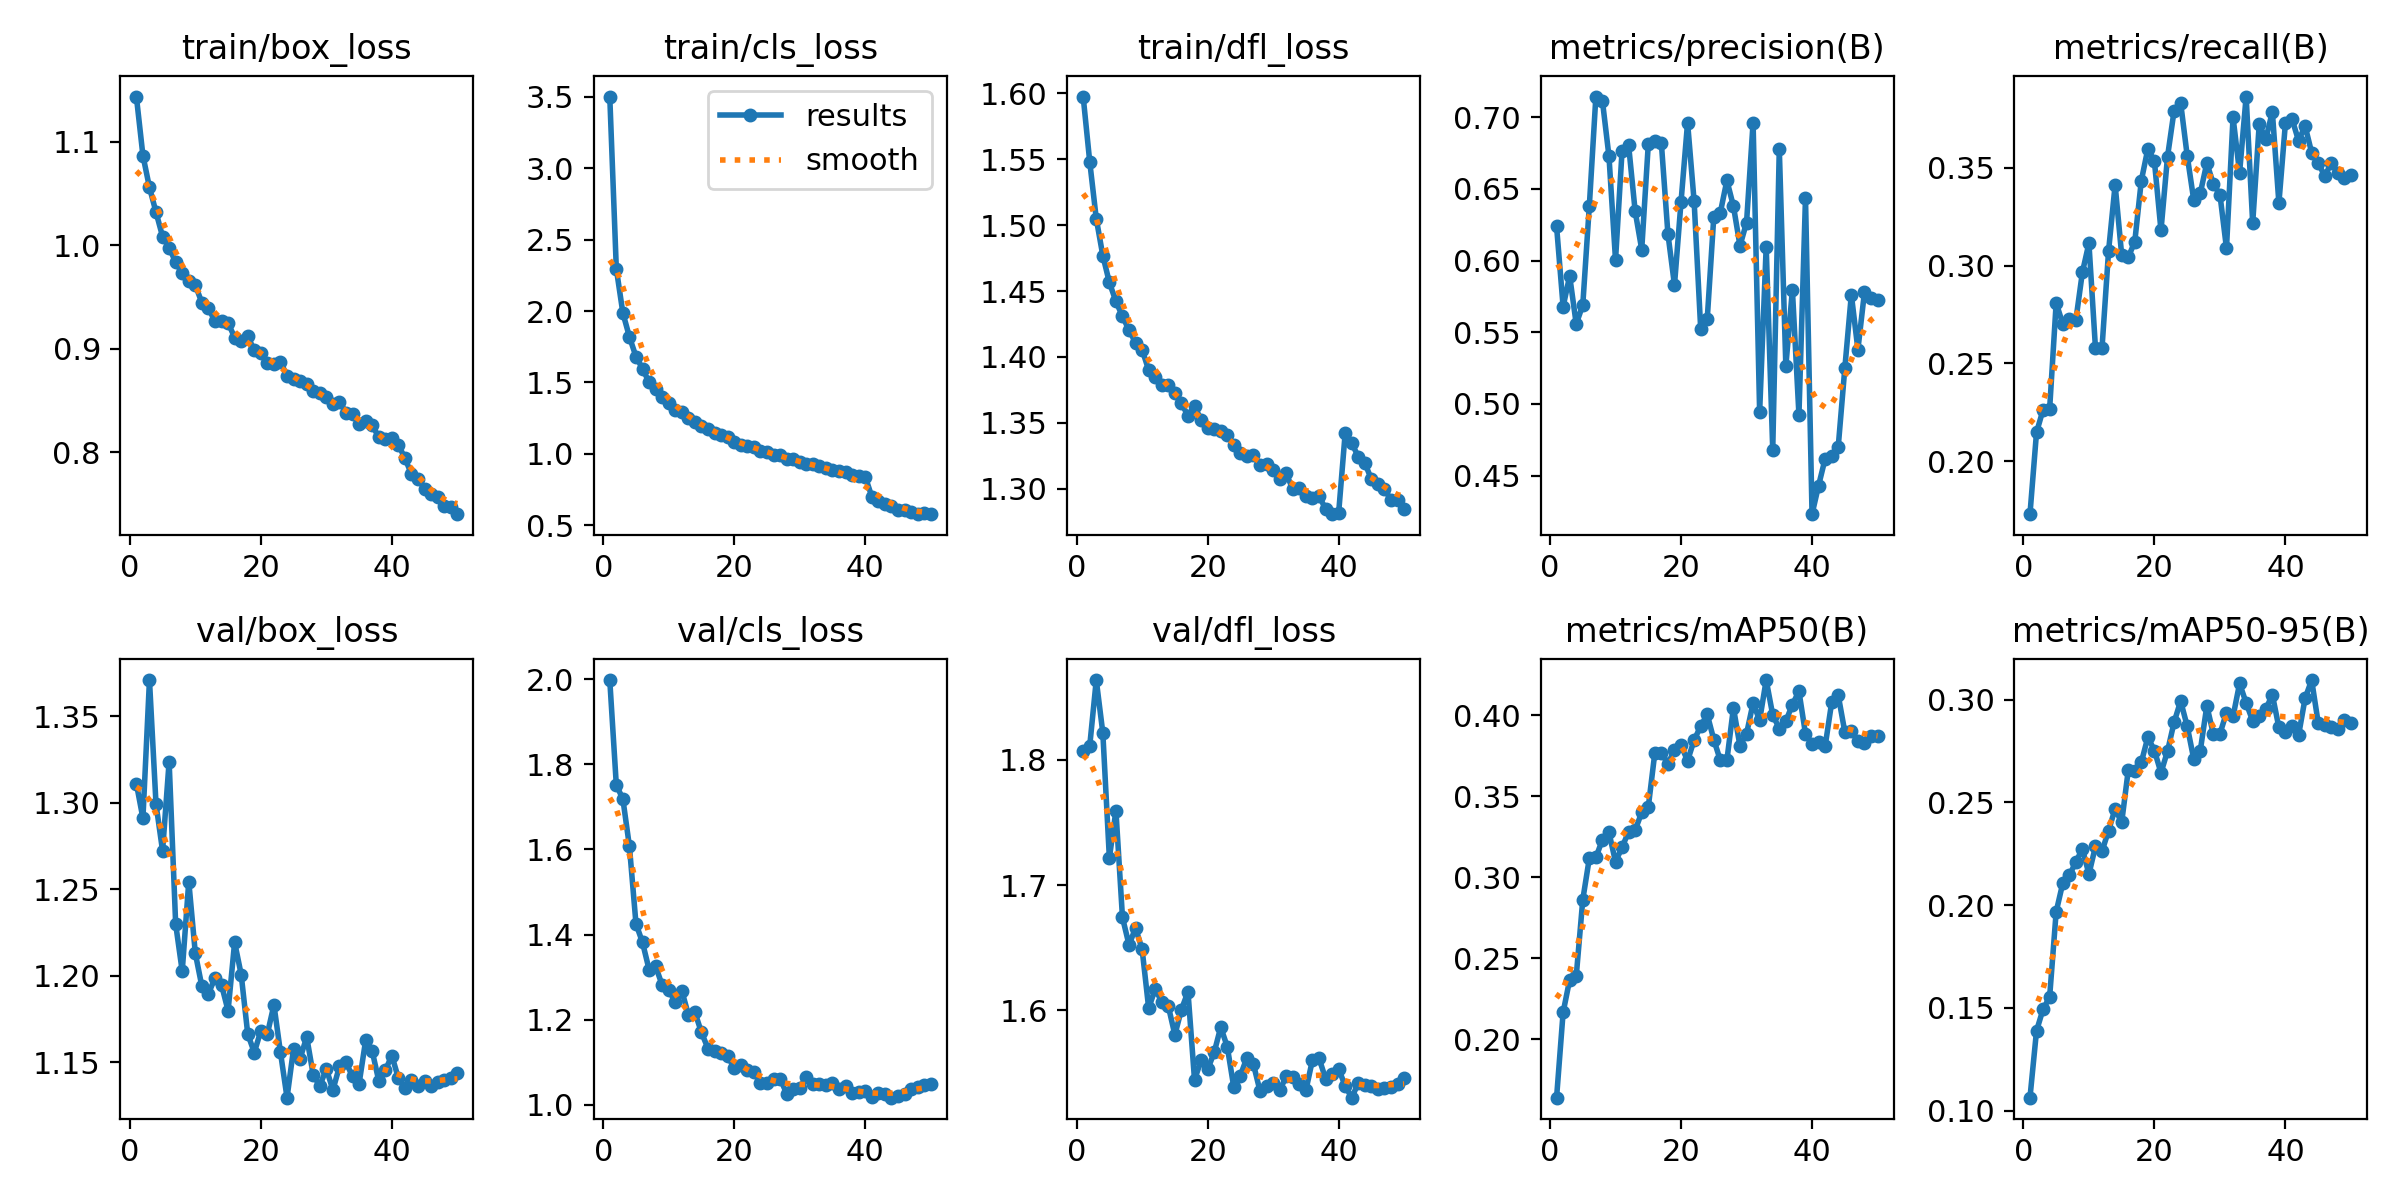

--------------------------------------------------
🎯 2. 混淆矩陣（各類垃圾辨識精準度矩陣）
--------------------------------------------------


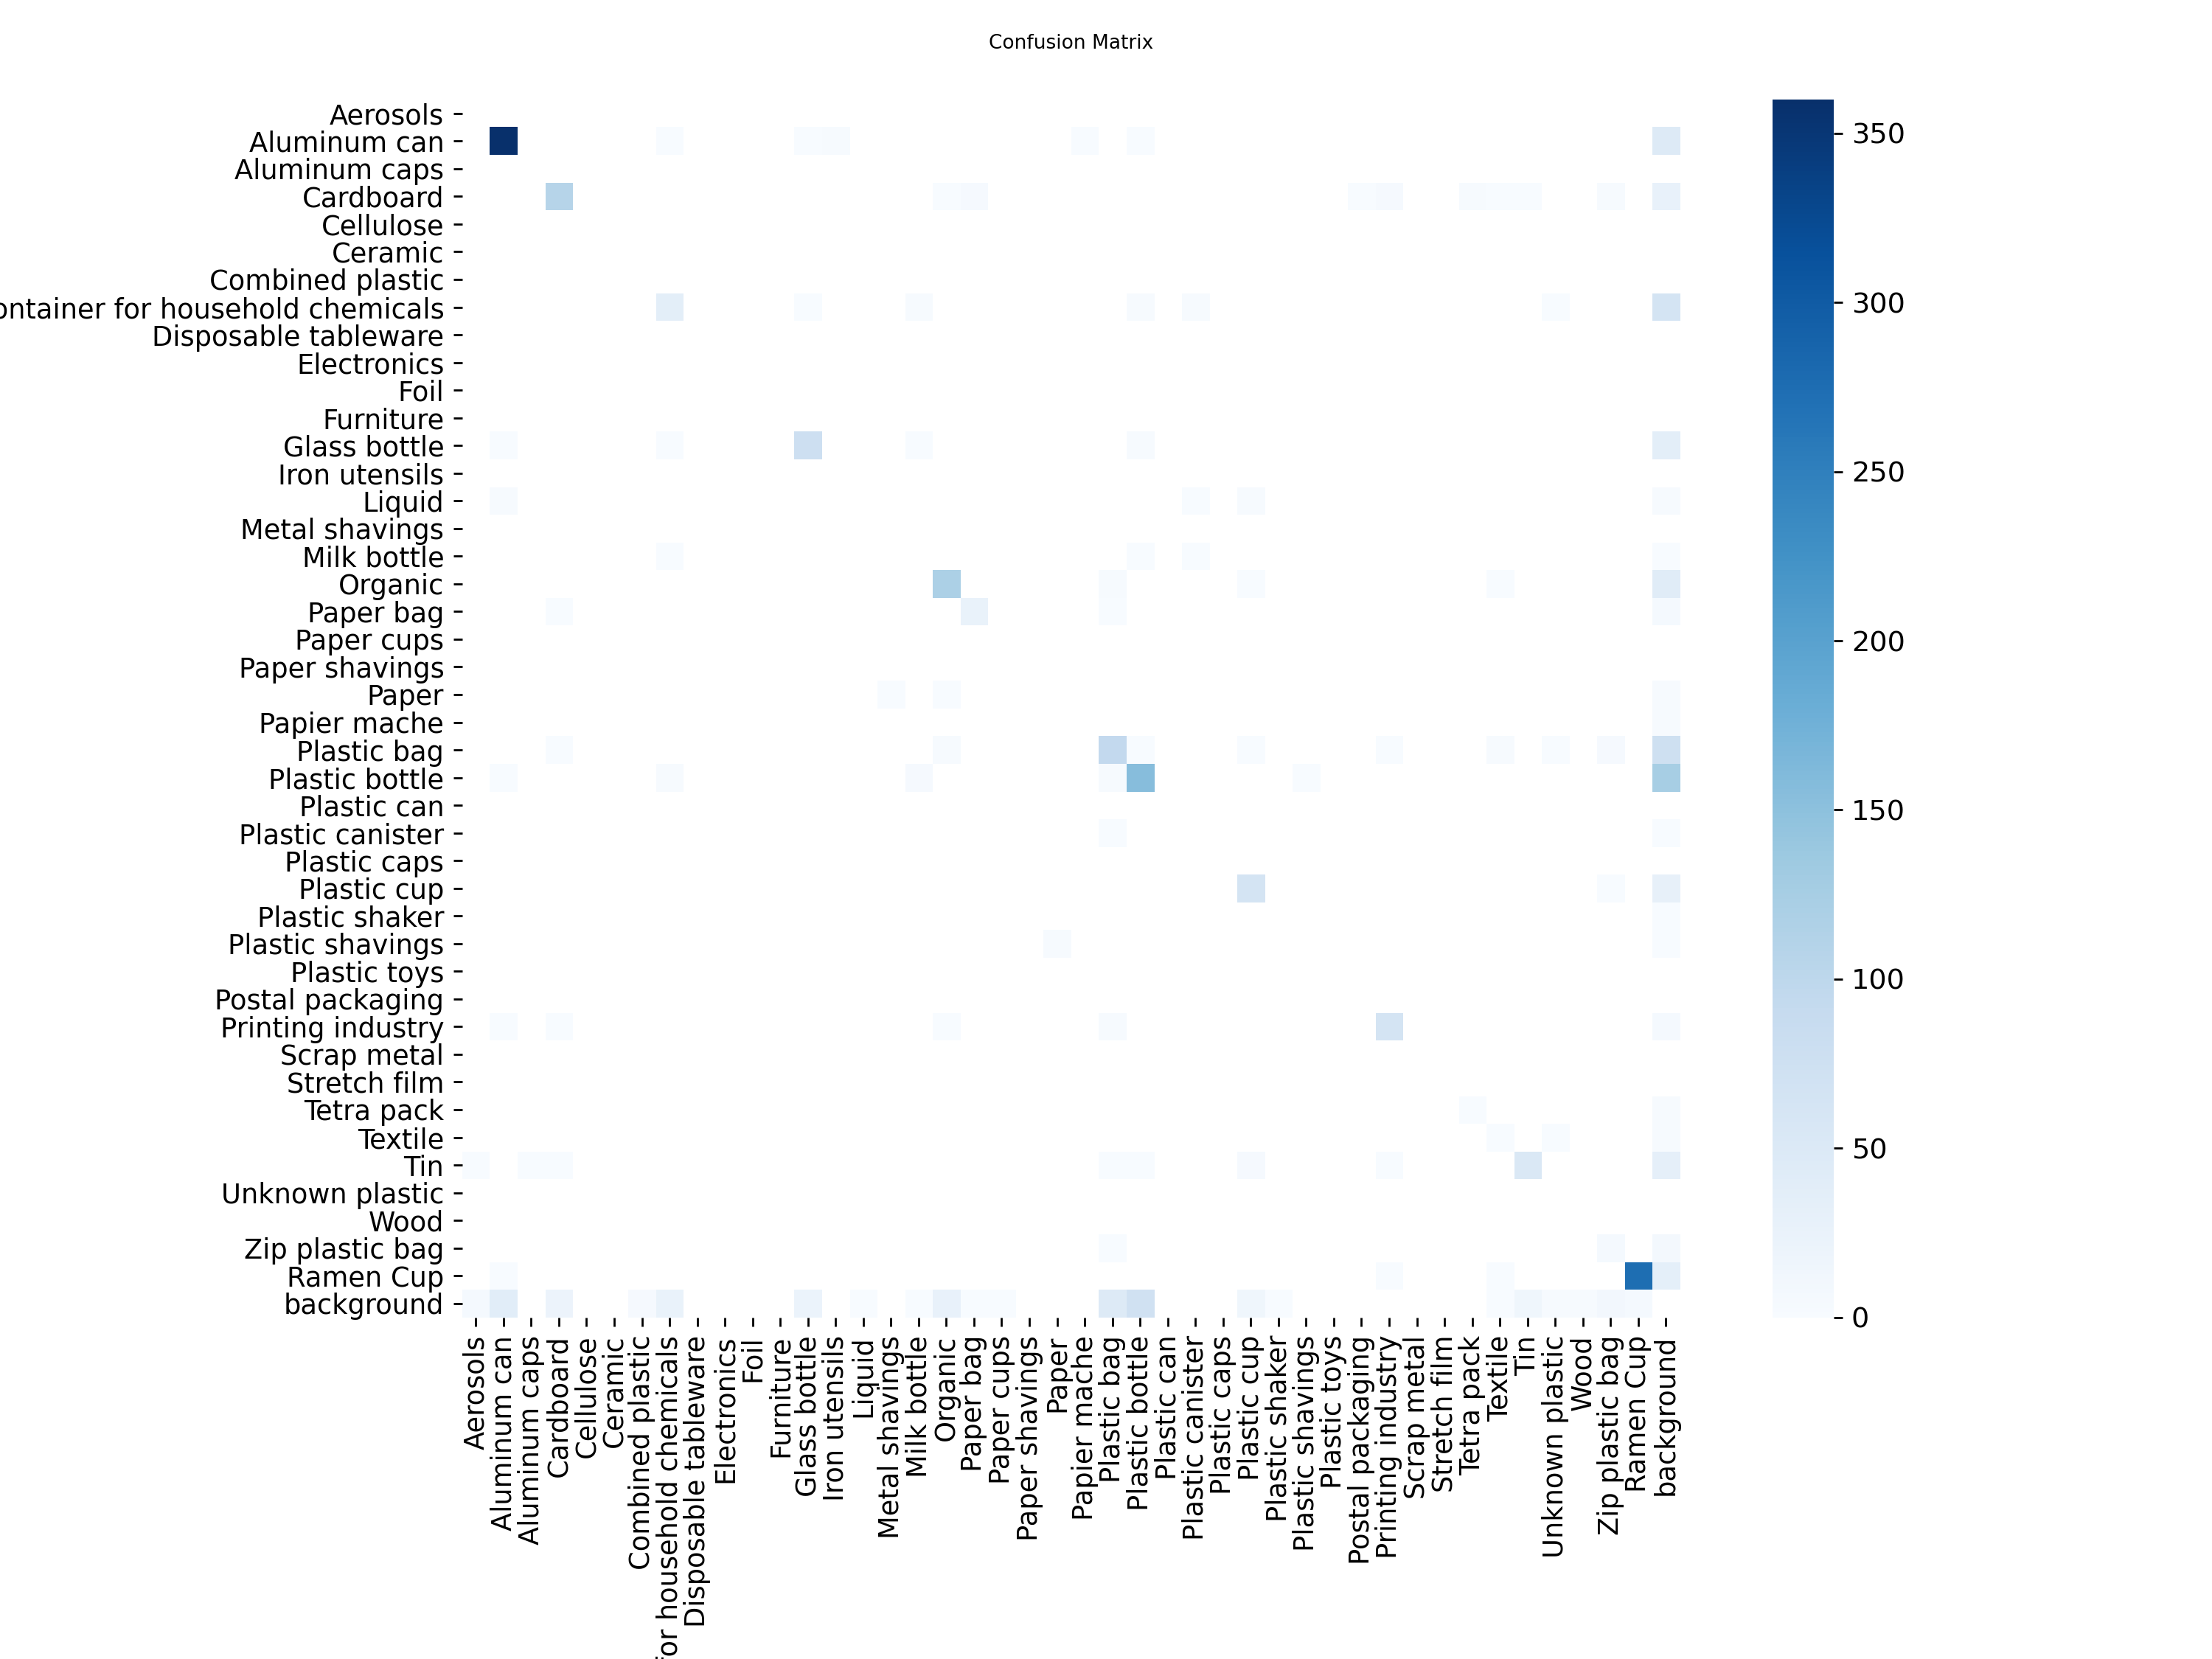

⚠️ 提示：在此目錄下未找到 F1_curve.png。
⚠️ 提示：在此目錄下未找到 labels.png。

🎉 所有現存數據圖已全數物理顯示完畢！


In [ ]:
import os
import glob
from IPython.display import Image, display

# 🎯 1. 自動鎖定 YOLOv8 訓練結果的輸出資料夾
result_dir = 'runs/detect/train'

if not os.path.exists(result_dir):
    # 防禦機制：如果今天跑了不只一次，自動抓最新（數字最大）的那個資料夾
    all_train_dirs = sorted(glob.glob('runs/detect/train*'))
    if all_train_dirs:
        result_dir = all_train_dirs[-1]

print(f"📂 成功鎖定訓練數據目錄: {result_dir}")
print("📊 正在將核心圖表物理顯示於下方（可直接右鍵另存圖片或截圖）：\n")

# 🎯 2. 計畫書必貼的四張核心數據圖
charts_to_display = [
    ('results.png', '📈 1. 綜合訓練曲線（Loss 下降與 mAP 爬升趨勢）'),
    ('confusion_matrix.png', '🎯 2. 混淆矩陣（各類垃圾辨識精準度矩陣）'),
    ('F1_curve.png', '🔥 3. F1-Confidence 曲線（模型綜合效能評估）'),
    ('labels.png', '📁 4. 資料集標籤分佈圖（確認標籤數量與框選物理狀態）')
]

# 🎯 3. 物理循環顯示
for chart_name, title in charts_to_display:
    chart_path = os.path.join(result_dir, chart_name)
    if os.path.exists(chart_path):
        print("-" * 50)
        print(title)
        print("-" * 50)
        display(Image(filename=chart_path, width=900))
    else:
        print(f"⚠️ 提示：在此目錄下未找到 {chart_name}。")

print("\n🎉 所有現存數據圖已全數物理顯示完畢！")

In [ ]:
import os
import glob
import pandas as pd
import yaml

# 🎯 1. 重新確認資料集的根目錄
dataset_root = "/content/dataset"
yaml_path = os.path.join(dataset_root, 'data.yaml')

# 🎯 2. 從 data.yaml 讀取訓練、驗證、測試集的路徑
if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        config_data = yaml.safe_load(f)

    train_labels_dir = os.path.join(dataset_root, config_data.get('train', 'train/images').replace('images', 'labels'))
    valid_labels_dir = os.path.join(dataset_root, config_data.get('val', 'valid/images').replace('images', 'labels'))
    test_labels_dir = os.path.join(dataset_root, config_data.get('test', 'test/images').replace('images', 'labels'))

    print("✅ 成功從 data.yaml 讀取到資料集分割路徑。")
else:
    print(f"⚠️ 警告：未找到 data.yaml 檔案於 {yaml_path}。將使用預設路徑。")
    train_labels_dir = os.path.join(dataset_root, 'train/labels')
    valid_labels_dir = os.path.join(dataset_root, 'valid/labels')
    test_labels_dir = os.path.join(dataset_root, 'test/labels')

# 🎯 3. 定義一個函數來計算指定資料夾中的標籤檔案數量
def count_label_files(directory):
    if os.path.exists(directory):
        return len(glob.glob(os.path.join(directory, '*.txt')))
    return 0

# 🎯 4. 計算各分割集的圖片數量
train_count = count_label_files(train_labels_dir)
valid_count = count_label_files(valid_labels_dir)
test_count = count_label_files(test_labels_dir)

# 🎯 5. 計算總圖片數量和比例
total_images = train_count + valid_count + test_count

data_split_list = []
if total_images > 0:
    data_split_list.append({
        "類型 (Type)": "訓練集 (Train)",
        "圖片張數 (Count)": train_count,
        "所佔比例 (Percentage)": f"{(train_count / total_images) * 100:.2f}%"
    })
    data_split_list.append({
        "類型 (Type)": "驗證集 (Valid)",
        "圖片張數 (Count)": valid_count,
        "所佔比例 (Percentage)": f"{(valid_count / total_images) * 100:.2f}%"
    })
    data_split_list.append({
        "類型 (Type)": "測試集 (Test)",
        "圖片張數 (Count)": test_count,
        "所佔比例 (Percentage)": f"{(test_count / total_images) * 100:.2f}%"
    })
else:
    print("🚫 警告：所有資料分割集中的圖片總數為零，無法計算比例。")

# 🎯 6. 轉成 Pandas DataFrame 並顯示結果
df_splits = pd.DataFrame(data_split_list)

print("\n📊 【資料集分割比例統計表】")
print("=" * 60)
print(f"📈 整個資料集總圖片張數：{total_images} 張")
print("=" * 60)
display(df_splits)
print("=" * 60)

✅ 成功從 data.yaml 讀取到資料集分割路徑。

📊 【資料集分割比例統計表】
📈 整個資料集總圖片張數：22004 張


,類型 (Type),圖片張數 (Count),所佔比例 (Percentage)
0,訓練集 (Train),19029,86.48%
1,驗證集 (Valid),2013,9.15%
2,測試集 (Test),962,4.37%


In [ ]:
import os
from google.colab import files

# 定義原始檔案路徑和壓縮檔名
mlpackage_path = '/content/runs/detect/train/weights/best.mlpackage'
zip_file_name = 'best.zip'

# 檢查原始檔案是否存在
if os.path.exists(mlpackage_path):
    print(f"📦 正在將 {mlpackage_path} 壓縮為 {zip_file_name}...")
    # 使用 zip 命令壓縮資料夾。-r 選項會遞迴壓縮所有子目錄和檔案。
    # 壓縮後會包含 best.mlpackage/ 的目錄結構在 zip 檔內
    !zip -r {zip_file_name} {mlpackage_path}

    # 檢查壓縮檔是否成功建立
    if os.path.exists(zip_file_name):
        print(f"✅ {zip_file_name} 壓縮檔已建立。正在提供下載...")
        files.download(zip_file_name)
        print("✅ 壓縮檔下載完成！")
    else:
        print(f"❌ 錯誤：無法建立 {zip_file_name} 壓縮檔。")
else:
    print(f"⚠️ 錯誤：原始檔案或目錄 {mlpackage_path} 不存在，無法進行壓縮與下載。")

📦 正在將 /content/runs/detect/train/weights/best.mlpackage 壓縮為 best.zip...
  adding: content/runs/detect/train/weights/best.mlpackage/ (stored 0%)
  adding: content/runs/detect/train/weights/best.mlpackage/Data/ (stored 0%)
  adding: content/runs/detect/train/weights/best.mlpackage/Data/com.apple.CoreML/ (stored 0%)
  adding: content/runs/detect/train/weights/best.mlpackage/Data/com.apple.CoreML/weights/ (stored 0%)
  adding: content/runs/detect/train/weights/best.mlpackage/Data/com.apple.CoreML/weights/weight.bin (deflated 8%)
  adding: content/runs/detect/train/weights/best.mlpackage/Data/com.apple.CoreML/model.mlmodel (deflated 87%)
  adding: content/runs/detect/train/weights/best.mlpackage/Manifest.json (deflated 60%)
  adding: content/runs/detect/train/weights/best.mlpackage/.ipynb_checkpoints/ (stored 0%)
✅ best.zip 壓縮檔已建立。正在提供下載...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 壓縮檔下載完成！
